In [1]:
# моделирование линейной системы
# взаимодействующих друг с другом
# магнитных спинов

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение метода norm из библиотеки stat
from scipy.stats import norm


In [ ]:
# Ячейка № 2

# задание функции, возвращающей мгновенные значения:
# полной энергии системы;
# энергии демона;
# суммарного магнитного момента
# моделируемой системы
def Ising_KA(N_Spin, J, h, N_Trial, T):
    # N_Spin - число спинов решетки
    # J - константа обменного взаимодействия
    # h - внешнее магнитное поле
    # N_Trial - число независимых испытаний в методе Монте-Карло
    # T - температура системы спинов

    s = np.zeros([N_Spin, N_Trial + 1])

    # инициализация начальной конфигурации спинов
    S = np.ones(N_Spin)

    s[:, 0] = np.sum(S)
    # вычисление начального значения энергии системы
    E_System_Test = int(-(J + h) * N_Spin)

    # инициализация массивов, используемых
    # для хранения мгновенных значений:
    # полной энергии системы (E_System);
    # суммарного магнитного момента
    # моделируемой системы (Summry_Spin_Moment)
    E_System = np.zeros(N_Trial * N_Spin + 1)
    Summary_Spin_Moment = np.zeros(N_Trial * N_Spin + 1)
    Accept = np.zeros(N_Trial * N_Spin + 1)

    # сохранение начальных значений
    # полной энергии системы;
    # энергии демона;
    # суммарного магнитного момента
    # моделируемой системы (Summry_Spin_Moment)
    E_System[0] = E_System_Test
    Summary_Spin_Moment[0] = np.sum(S)

    # реализация метода микроканонического ансамбля
    k = 0

    for i in range(1, N_Trial + 1):
        # подсчитываем число принятых
        # пробных переворотов спинов
        # на каждом шаге метода Монте-Карло
        N_Accept = 0
        for j in range(N_Spin):
            # случайный переворачиваемого спина
            I_Spin = int(random.uniform(0, N_Spin))
            # выбираем номера соседних
            # с переворачиваемым спином
            # с учетом периодических граничных условий
            if I_Spin == 0:
                Left = S[N_Spin - 1]
                Right = S[1]
            if I_Spin == N_Spin - 1:
                Left = S[N_Spin - 2]
                Right = S[0]

            # задаем номера соседних спинов,
            # если переворачиваемый спин
            # не находится на границе одномерной области
            if I_Spin != 0:
                Left = I_Spin - 1
                Right = I_Spin + 1

            # вычисление энергии спина
            # после его пробного переворота
            D_E = 2 * S[I_Spin] * (-h + J * (Left + Right))

            if D_E <= 0 or (D_E > 0 and random.uniform(0, 1) <= np.exp(-D_E / T)):
                # изменение ориентации спина принимается

                S[I_Spin] = -S[I_Spin]
                N_Accept = N_Accept + 1
                E_System_Test = E_System_Test + D_E
            k = k + 1
            # сохранение на каждом шаге
            # алгоритма Метрополиса значений:
            # энергии системы, энергии демона,
            # среднего магнитного момента системы спинов,
            # числа принятых пробных переворотов спина,
            # нормированного на число спинов,
            # текущей конфигурации спинов
            E_System[k] = E_System_Test
            Summary_Spin_Moment[k] = np.sum(S)
            Accept[k] = N_Accept / N_Spin
        s[:, i] = S[:]

    return E_System, Summary_Spin_Moment, Accept, s


In [ ]:
# Ячейка № 3

# вычисление и визуализация
# последовательностей, составленных из
# мгновенных значений энергий системы спинов,
# суммарного магнитного момента системы спинов,
# мгновенного числа принятых решений

# инициализация генератора случайных чисел
random.seed()

# задание числа спинов
N_Spin = 200

# задание значения спина
J = 1

# задание напряженности магнитного поля
h = 0

# задание числа испытаний метода Монте-Карло
N_Trial = 4000

# задание температуры системы спинов
T = 100

# вычисление последовательностей,
# составленных из мгновенных значений
# энергии системы спинов,
# суммарного магнитного момента
# системы спинов,
# числа принятых пробных изменений
# энергии системы спинов
[E_System, Summary_Spin_Moment, Accept, s] = Ising_KA(N_Spin, J, h, N_Trial, T)


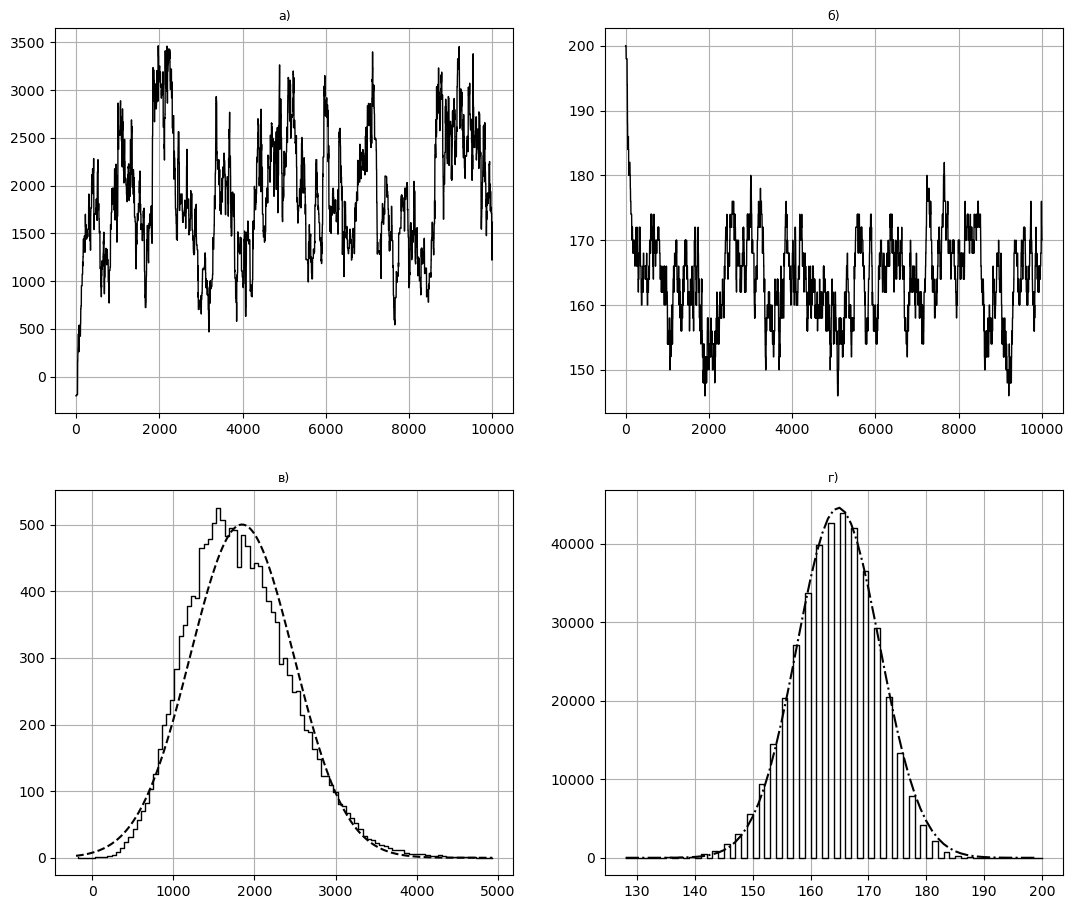

In [4]:
# Ячейка № 4

# визуализация последовательностей,
# составленных из мгновенных значений
# энергии моделируемой системы,
# полного магнитного момента системы и
# их эмпирических плотностей распределений

fig = plt.figure(figsize=(13, 11))

# визуализация последовательности,
# составленной из мгновенных значений
# энергии системы
ax = plt.subplot(2, 2, 1)
plt.plot(E_System[0:10000], "-k", lw=1)
plt.grid(True)
ax.set_title("а)", fontsize=9)

ax = plt.subplot(2, 2, 2)
plt.plot(Summary_Spin_Moment[0:10000], "-k", lw=1)
plt.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация распределения последовательности,
# составленной из мгновенных значений энергии
# одномерной системы спинов, и соответствующего
# нормального закона распределения

# вычисление значений эмпирической
# эмпирической плотности распределения
N_bin = 100
H = np.histogram(E_System, bins=N_bin)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

# вычисление координат узлов сетки,
# используемых для вычисления значений
# плотности соответствующего
# нормального распределения
N_bin = 200
xbins = np.arange(
    np.min(E_System), np.max(E_System), (max(E_System) - min(E_System)) / N_bin
)

# вычисление значения плотности
# соответствующего нормального распределения
# N(x,np.mean(E_System),np.std(E_System)),
# в качестве параметров которого использованы
# их оценки, вычисленные на основе значений,
# находящихся в массиве E_System
dP_est = norm.pdf(xbins, np.mean(E_System), np.std(E_System))

# визуализация эмпирической
# плотности распределения
# и соответствующего нормального распределения
ax = plt.subplot(2, 2, 3)
plt.step(x, H[0] / (x[1] - x[0]), "-k", lw=1)
plt.plot(xbins, len(E_System) * dP_est, "--k")
plt.grid(True)
ax.set_title("в)", fontsize=9)

# визуализация эмпирической плотности
# распределения последовательности,
# составленной из мгновенных значений суммарного
# магнитного момента одномерной системы спинов,
# и аппроксимации данного нормального закона распределения

# вычисление эмпирической
# плотности распределения
# мгновенных значений энергии
# системы спинов

# задание числа интервалов гистограммы,
# обеспечивающего целое значение
# длины интервала гистограммы
N_bin = np.max(Summary_Spin_Moment.astype(int)) - np.min(
    Summary_Spin_Moment.astype(int)
)
H = np.histogram(Summary_Spin_Moment, bins=N_bin)

# формирование из упорядоченной последовательности
# последовательности элементов H,
# возвращаемой функцией histogram,
# массивов, содержащих значения
# левых границ интервалов гистограммы (массив H1), и
# число членов случайной последовательности,
# попавших в данный интервал гистограммы (массив H2)
H1 = np.zeros(int(len(H[1])))
H2 = np.zeros(int(len(H[1])))
k = 0

for i in range(len(H[1])):
    H2[k] = H[1][i]
    k = k + 1
k = 0

H1 = H1.astype(int)
for i in range(len(H[0]) - 1):
    H1[k] = H[0][i]
    k = k + 1
H1[k] = H[0][len(H[0]) - 1]

# вычисление координат узлов сетки,
# в которых вычисляются значения
# теоретической плотности распределения,
# используемой для аппроксимации эмпирической
# плотности распределения последовательности,
# составленной из мгновенных значений
# суммарного магнитного момента
# линейной системы спинов
N_bin = np.max(Summary_Spin_Moment) - np.min(Summary_Spin_Moment)
xbins = np.arange(
    np.min(Summary_Spin_Moment),
    np.max(Summary_Spin_Moment),
    (max(Summary_Spin_Moment) - min(Summary_Spin_Moment)) / N_bin,
)

# вычисление значения плотности
# нормального распределения
# N(x,np.mean(Summary_Spin_Moment),np.std(Summary_Spin_Moment)),
# в качестве параметров которого использованы
# их оценки, вычисленные на основе значений,
# находящихся в массиве Summary_Spin_Moment
dP_est = norm.pdf(xbins, np.mean(Summary_Spin_Moment), np.std(Summary_Spin_Moment))

# визуализация эмпирической плотности распределения
# и его аппроксимации соответствующим
# нормальным распределением
ax = plt.subplot(2, 2, 4)

# при построении гистограммы массив H1
# нормируется на удвоенное значение длины
# интервала гистограммы, так как значения
# последовательных дискретных случайных величин,
# отличаются друг от друга на плюс/минус 2
plt.step(H2, H1 / (2 * (H2[1] - H2[0])), "-k", lw=1)
plt.plot(xbins, len(Summary_Spin_Moment) * dP_est, "-.k")
plt.grid(True)
ax.set_title("г)", fontsize=9)
plt.show()

In [5]:
print("H2 = ", H2)
print("H1 = ", H1)

H2 =  [128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140. 141.
 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154. 155.
 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167. 168. 169.
 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181. 182. 183.
 184. 185. 186. 187. 188. 189. 190. 191. 192. 193. 194. 195. 196. 197.
 198. 199. 200.]
H1 =  [    4     0    15     0    17     0    26     0    75     0   175     0
   291     0   869     0  1678     0  3547     0  6059     0 11044     0
 18885     0 28910     0 40594     0 54158     0 67428     0 79749     0
 85222     0 87813     0 83962     0 72969     0 58420     0 41024     0
 26607     0 15673     0  8230     0  4187     0  1576     0   489     0
   217     0    43     0     3     0     5     0     1     0    24    12
     0]
